In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from scipy.stats import ttest_1samp
from scipy.ndimage import gaussian_filter

import cmocean
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.colors as mcolors

In [2]:
class SurfaceVariableDifferencePlotter:
    def __init__(self, data_dict, landmask_file=None,
                 variable='PRECT', obs_variable=None,
                 fscale=None, obs_fscale=None,
                 landmask_var='landfrac', mask_land=True,
                 confidence_level=0.05):
        self.data_dict = data_dict
        self.variable = variable
        self.obs_variable = obs_variable or variable
        self.fscale = fscale or 1.0
        self.obs_fscale = obs_fscale or 1.0
        self.landmask_var = landmask_var
        self.mask_land = mask_land
        self.confidence_level = confidence_level

        self.landmask = None
        if landmask_file and os.path.exists(landmask_file):
            ds_mask = xr.open_dataset(landmask_file)
            self.landmask = ds_mask[self.landmask_var]
            lon_name = next((k for k in self.landmask.coords if k.lower() in ['lon', 'longitude']), None)
            if lon_name:
                lon = self.landmask[lon_name]
                if lon.min() < 0 or lon.max() > 360:
                    new_lon = (lon % 360).sortby(lon)
                    self.landmask = self.landmask.assign_coords({lon_name: new_lon}).sortby(lon_name)

    def _apply_landmask(self, da):
        if self.mask_land and self.landmask is not None:
            landmask_interp = self.landmask.interp_like(da, method='nearest')
            return da.where(landmask_interp > 0.5)
        return da

    def _load_dataset(self, info, year, ensemble=None):
        template = info['template']
        path = info['path']
        filename = template % {'year': year, 'ensemble': ensemble} if ensemble else template % {'year': year}
        full_path = os.path.join(path, filename)
        if not os.path.exists(full_path):
            raise FileNotFoundError(f"[ERROR] File not found: {full_path}")
        return xr.open_dataset(full_path)

    def _wrap_longitude_for_plot(self, da):
        if 'lon' not in da.coords:
            return da
        lon = da.lon
        if (lon[-1] - lon[0]) < 359:
            da = da.pad(lon=(0, 1), constant_values=np.nan)
            da['lon'][-1] = da['lon'][0] + 360
        return da

    def _load_model_ensemble_snapshot(self, model_info, target_date):
        nens = model_info['nens']
        ens_data = []
        for n in range(1, nens + 1):
            ens = f'EN{n:02d}'
            ds = self._load_dataset(model_info, target_date.year, ensemble=ens)
            ds_day = ds[self.variable].sel(time=target_date) * self.fscale
            ens_data.append(ds_day.squeeze())
        return xr.concat(ens_data, dim='ensemble')

    def _load_obs_snapshot(self, obs_info, target_date):
        ds = self._load_dataset(obs_info, target_date.year)
        obs = ds[self.obs_variable].sel(time=target_date) * self.obs_fscale
        lon_name = next((k for k in obs.coords if k.lower() in ['lon', 'longitude']), None)
        if lon_name:
            lon = obs[lon_name]
            if lon.min() < 0 or lon.max() > 360:
                new_lon = (lon % 360).sortby(lon)
                obs = obs.assign_coords({lon_name: new_lon}).sortby(lon_name)
        return self._apply_landmask(obs)

    def _compute_significance_mask(self, ensemble_data, obs_mean, alpha=0.05):
        diff = ensemble_data - obs_mean
        tstat, pvals = ttest_1samp(diff.transpose("ensemble", "lat", "lon").values,
                                   popmean=0.0, axis=0, nan_policy='omit')
        return xr.DataArray(pvals < alpha, coords=obs_mean.coords, dims=obs_mean.dims)

    def plot_bias_and_stddev_multi_panel(self, model_keys, target_date='2012-01-01',
                                         obs_key='OBS', bias_levels=None, spread_levels=None,
                                         cmap_bias='RdBu_r', cmap_std='viridis',
                                         figsize=(12, 5), savepath=None, fontz=8):
        target_date = pd.to_datetime(target_date)
        ncols = len(model_keys)

        if bias_levels is None:
            bias_levels = [-5, -3, -1, -0.5, -0.1, 0.1, 0.5, 1, 3, 5]
        if spread_levels is None:
            spread_levels = [0.1, 0.5, 1, 1.5, 2, 2.5]

        bias_cmap = plt.get_cmap(cmap_bias)
        spread_cmap = plt.get_cmap(cmap_std)
        bias_norm = mcolors.BoundaryNorm(bias_levels, bias_cmap.N)
        spread_norm = mcolors.BoundaryNorm(spread_levels, spread_cmap.N)

        fig, axes = plt.subplots(2, ncols, figsize=figsize, subplot_kw={'projection': ccrs.Robinson()})

        for j, model_key in enumerate(model_keys):
            model_info = self.data_dict[model_key]
            obs_info = self.data_dict[obs_key]

            ens_stack = self._load_model_ensemble_snapshot(model_info, target_date)
            obs_field = self._load_obs_snapshot(obs_info, target_date)

            if ens_stack.shape[1:] != obs_field.shape:
                ens_stack = ens_stack.interp_like(obs_field)

            model_mean = ens_stack.mean(dim='ensemble')
            model_std = ens_stack.std(dim='ensemble')
            bias = model_mean - obs_field

            model_mean = self._apply_landmask(model_mean)
            model_std = self._apply_landmask(model_std)
            bias = self._apply_landmask(bias)

            model_mean = self._wrap_longitude_for_plot(model_mean)
            bias = self._wrap_longitude_for_plot(bias)
            model_std = self._wrap_longitude_for_plot(model_std)

            model_vals = model_mean.values.flatten()
            obs_vals = obs_field.values.flatten()
            valid = np.isfinite(model_vals) & np.isfinite(obs_vals)
            pcc = np.corrcoef(model_vals[valid], obs_vals[valid])[0, 1]
            rmse_val = float(np.sqrt(((model_vals[valid] - obs_vals[valid]) ** 2).mean()))

            ax0 = axes[0, j]
            ax0.contourf(bias['lon'], bias['lat'], bias,
                         levels=bias_levels, cmap=bias_cmap,
                         norm=bias_norm, transform=ccrs.PlateCarree(),
                         extend='both')
            ax0.set_title(f"{model_key} - {obs_key} (Bias)", fontsize=fontz)
            ax0.coastlines(linewidth=0.4)
            ax0.text(
                0.98, 0.02, f"PCC: {pcc:.2f}\nRMSE: {rmse_val:.2f}",
                transform=ax0.transAxes, fontsize=fontz - 2, va='bottom', ha='right',
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')
            )
            sig_mask = self._compute_significance_mask(ens_stack, obs_field, alpha=self.confidence_level)
            sig_mask = self._apply_landmask(sig_mask)
            sig_mask.plot.contourf(ax=ax0, transform=ccrs.PlateCarree(),
                                   colors='none', hatches=['..'], add_colorbar=False, add_labels=False)

            ax1 = axes[1, j]
            ax1.contourf(model_std['lon'], model_std['lat'], model_std,
                         levels=spread_levels, cmap=spread_cmap,
                         norm=spread_norm, transform=ccrs.PlateCarree(),
                         extend='both')
            ax1.set_title(f"{model_key} Spread", fontsize=fontz)
            ax1.coastlines(linewidth=0.4)

        plt.subplots_adjust(wspace=0.1, hspace=0.2, right=0.88)

        cbar_ax1 = fig.add_axes([0.90, 0.60, 0.01, 0.30])
        sm1 = mpl.cm.ScalarMappable(norm=bias_norm, cmap=bias_cmap)
        sm1.set_array([])
        fig.colorbar(sm1, cax=cbar_ax1, label="Bias", extend='both')
        cbar_ax1.yaxis.label.set_size(fontz)

        cbar_ax2 = fig.add_axes([0.90, 0.18, 0.01, 0.30])
        sm2 = mpl.cm.ScalarMappable(norm=spread_norm, cmap=spread_cmap)
        sm2.set_array([])
        fig.colorbar(sm2, cax=cbar_ax2, label="Spread", extend='both')
        cbar_ax2.yaxis.label.set_size(fontz)

        if savepath:
            fig.savefig(savepath, dpi=600, bbox_inches='tight')
            print(f"[SAVED] Figure saved to: {savepath}")
        plt.show()


/global/common/software/e3sm/anaconda_envs/base/envs/e3sm_unified_1.10.0_login/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:577: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return result_to_tuple(hypotest_fun_out(*samples, **kwds))
/global/common/software/e3sm/anaconda_envs/base/envs/e3sm_unified_1.10.0_login/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:577: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return result_to_tuple(hypotest_fun_out(*samples, **kwds))
/global/common/software/e3sm/anaconda_envs/base/envs/e3sm_unified_1.10.0_login/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:577: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This 

[SAVED] Figure saved to: /global/homes/z/zhan391/analysis/diagnostic/figures/PRECT_bias_stddev_vs_GPCP_20120101.pdf


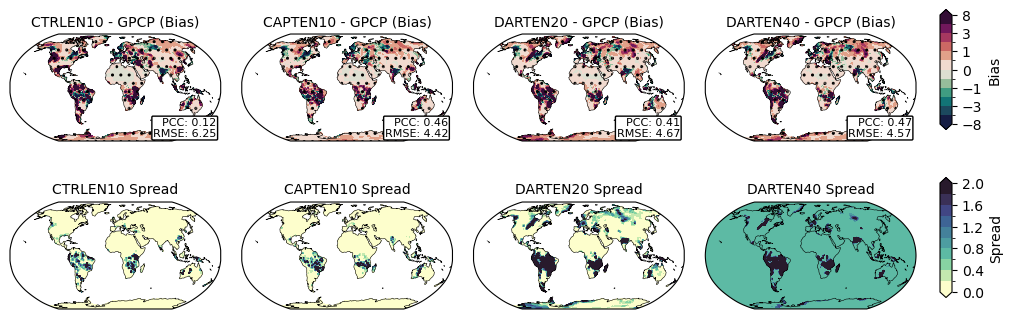

In [3]:
if __name__ == "__main__":
    # Paths
    top_path = "/pscratch/sd/z/zhan391/e3sm_dart"
    out_path = os.path.join(top_path, "diag_dart")
    fig_path = "/global/homes/z/zhan391/analysis/diagnostic/figures"
    os.makedirs(fig_path, exist_ok=True)

    landmask_file = os.path.join(out_path, "landmask_1x1.nc")

    # Data sources
    data_dict = {
        'GPCP': {
            'path': f'{top_path}/Observations/GPCP/daily',
            'template': 'PRECT.daily.%(year)s.nc',
            'frequency': 'daily',
            'nens': 1
        },
        'ERA5': {
            'path': f'{top_path}/Observations/ERA5/6hourly',
            'template': 'ERA5.6hourly.en00.TREFHT.%(year)s01-%(year)s12.nc',
            'frequency': '6hourly',
            'nens': 1
        },
        'CTRLEN10': {
            'path': f'{top_path}/CTRLEN10_15day_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/atm/180x360_aave/ts/daily',
            'template': 'PRECT.%(ensemble)s.%(year)s.nc',
            'frequency': 'daily',
            'nens': 10
        },
        'CAPTEN10': {
            'path': f'{top_path}/CAPTEN10_15day_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/atm/180x360_aave/ts/daily',
            'template': 'PRECT.%(ensemble)s.%(year)s.nc',
            'frequency': 'daily',
            'nens': 10
        },
        'DARTEN20': {
            'path': f'{top_path}/DARTEN20_15day_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/atm/180x360_aave/ts/daily',
            'template': 'PRECT.%(ensemble)s.%(year)s.nc',
            'frequency': 'daily',
            'nens': 20
        },
        'DARTEN40': {
            'path': f'{top_path}/DARTEN40_15day_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/atm/180x360_aave/ts/daily',
            'template': 'PRECT.%(ensemble)s.%(year)s.nc',
            'frequency': 'daily',
            'nens': 40
        }
    }

    # Configuration
    model_keys = ['CTRLEN10', 'CAPTEN10', 'DARTEN20', 'DARTEN40']
    target_date = '2012-01-01'
    obs_key = 'GPCP'
    obs_variable='PRECT'
    obs_fscale = 1.0
    variable='PRECT'
    fscale = 86400000.0 
    bias_levels = [-8,-5,-3,-2,-1,-0.1,0,0.1,1,2,3,5,8]  #np.linspace(-5,5,11) #[-1.0,-0.8,-0.6,-0.4,-0.2,-0.1,0.1,0.2,0.4,0.6,0.8,1.0]
    #spread_levels = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
    spread_levels = np.linspace(0,2,11)
    fontz = 10

    combined_savefile = os.path.join(
        fig_path, f"{variable}_bias_stddev_vs_{obs_key}_{target_date.replace('-', '')}.pdf"
    )
    
    plotter = SurfaceVariableDifferencePlotter(
        data_dict=data_dict,
        variable=variable, 
        fscale = fscale, 
        obs_variable=obs_variable,  
        obs_fscale = obs_fscale,   
        landmask_file=landmask_file
    )
    
    plotter.plot_bias_and_stddev_multi_panel(
        model_keys=model_keys,
        target_date=target_date,
        obs_key=obs_key,
        bias_levels=bias_levels,
        spread_levels=spread_levels,
        figsize=(12,4),
        fontz=fontz,
        cmap_bias=cmocean.cm.curl,
        cmap_std=cmocean.cm.deep,
        savepath=combined_savefile
    )